# Transfer Learning for NLP with TensorFlow Hub

Diese Notebook-Vorlage nutzt die Docker-/Cursor-Umgebung dieses Projekts.  Zuerst wurde `train.csv` unter `data/raw/` abgelegt 

In [10]:
from tfhub_lab.data import load_dataset, split_dataset


TensorFlow: 2.16.2
TF Hub: 0.16.1
(1306122, 3)
(13061, 3)
(1293, 3)


147144     What is your experience living in Venezuela in...
978379     In which state/city the price of property is h...
588051     Do rich blacks also call poor whites, “White T...
1231527    Should my 5 yr old son and 2 yr old daughter s...
1284232                              Why do we have parents?
82148      Do we experience ghost like Murphy did in Inte...
1177278                       Are Estoniano women beautiful?
729509     There was a Funny or Die video called Sensitiv...
318720     Is it a good idea to go in fully mainstream cl...
223719        What classifies a third world country as such?
499558                                Is being a pilot safe?
223323     Who is Illiteratendra Modi? Why does he keep w...
1077082    Have modern management strategies such as Tota...
61998          Why are Lucky Charms considered good for you?
757807     How many people in India use WhatsApp, Faceboo...
Name: question_text, dtype: object

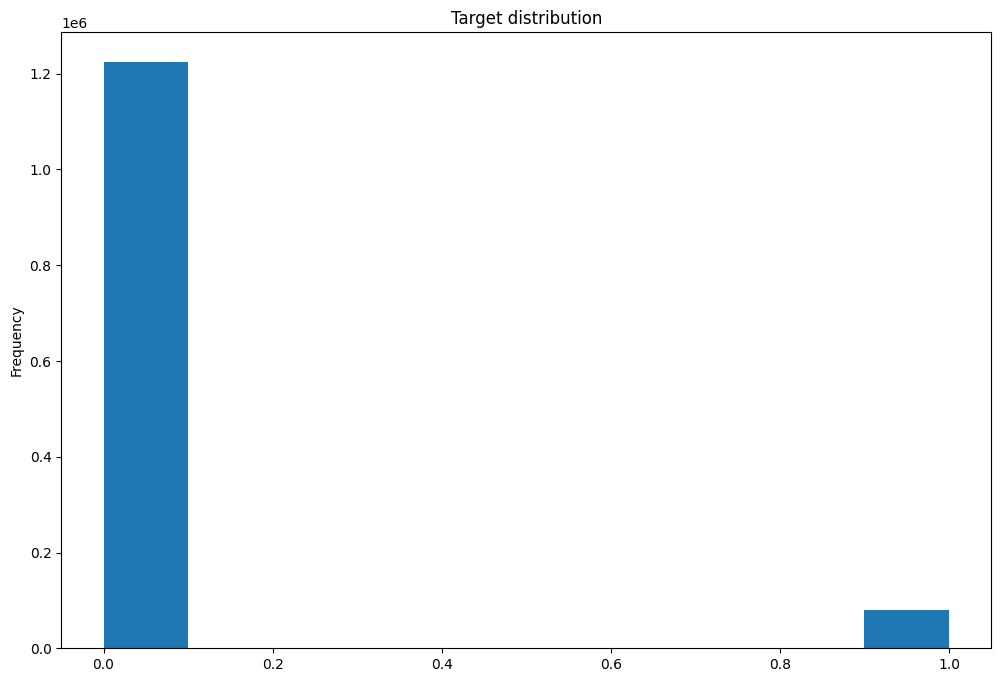

In [12]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MPLCONFIGDIR = PROJECT_ROOT / ".matplotlib"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split

from tfhub_lab.downloads import download_quora_train_zip
from tfhub_lab.data import load_dataset, split_dataset, to_tf_dataset
from tfhub_lab.modeling import build_model, get_model_spec

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
logdir = PROJECT_ROOT / "logs"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
logdir.mkdir(parents=True, exist_ok=True)

zip_path = download_quora_train_zip(RAW_DIR)
DATA_PATH = zip_path

print("TensorFlow:", tf.__version__)
print("TF Hub:", hub.__version__)

df = pd.read_csv(zip_path, compression="zip", low_memory=False)
print(df.shape)

df["target"].plot(kind="hist", title="Target distribution")

train_df, remaining = train_test_split(
    df,
    random_state =42,
    train_size= 0.01,
    stratify =df["target"]
)

valid_df, _ = train_test_split(
    remaining,
    random_state= 42,
    train_size=0.001,
    stratify=remaining["target"]
)

train_df.to_csv(PROCESSED_DIR/ "train_sample.csv", index=False)
valid_df.to_csv(PROCESSED_DIR / "valid_sample.csv", index=False)

print(train_df.shape)
print(valid_df.shape)

train_df.target.head(15)
train_df.question_text.head(15)


In [13]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from tfhub_lab.data import load_dataset, split_dataset

default_zip_path = PROJECT_ROOT / "data" / "raw" / "train.csv.zip"
default_csv_path = PROJECT_ROOT / "data" / "raw" / "train.csv"
DATA_PATH = globals().get(
    "DATA_PATH",
    default_zip_path if default_zip_path.exists() else default_csv_path,
)

frame = load_dataset(DATA_PATH, sample_size=20000)
train_frame, validation_frame, test_frame = split_dataset(frame)

print('Train:', len(train_frame))
print('Validation:', len(validation_frame))
print('Test:', len(test_frame))
frame.head()

Train: 14000
Validation: 2000
Test: 4000


,question_text,target
0,What is the most effective classroom managemen...,0
1,Can I study abroad after 10th class from Bangl...,0
2,How can I make friends as a college junior?,0
3,How do I download free APK Minecraft: Pocket E...,0
4,"Like Kuvera, is ""Groww"" also a free online inv...",0


In [14]:
batch_size = 256
train_ds = to_tf_dataset(train_frame, batch_size=batch_size, shuffle=True)
validation_ds = to_tf_dataset(validation_frame, batch_size=batch_size, shuffle=False)
test_ds = to_tf_dataset(test_frame, batch_size=batch_size, shuffle=False)

In [15]:
spec = get_model_spec('nnlm_50d')
model = build_model(spec)
model.summary()

Model: "nnlm_50d"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text (InputLayer)           [(None,)]                 0         
                                                                 
 embedding (KerasLayer)      (None, 50)                48190600  
                                                                 
 dense_4 (Dense)             (None, 64)                3264      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 prediction (Dense)          (None, 1)                 65        
                                                                 
Total params: 48193929 (183.85 MB)
Trainable params: 3329 (13.00 KB)
Non-trainable params: 48190600 (183.83 MB)
_________________________________________________________________


In [16]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=3,
    verbose=1,
)

results = model.evaluate(test_ds, return_dict=True)
results

Epoch 1/3
55/55 [==============================] - 1s 4ms/step - loss: 0.4755 - accuracy: 0.8784 - precision: 0.0551 - recall: 0.0558 - auc: 0.5016 - val_loss: 0.3045 - val_accuracy: 0.9360 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.5333
Epoch 2/3
55/55 [==============================] - 0s 1ms/step - loss: 0.2693 - accuracy: 0.9359 - precision: 0.0000e+00 - recall: 0.0000e+00 - auc: 0.5455 - val_loss: 0.2438 - val_accuracy: 0.9360 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.5987
Epoch 3/3
16/16 [==============================] - 0s 1ms/step - loss: 0.2243 - accuracy: 0.9360 - precision: 0.0000e+00 - recall: 0.0000e+00 - auc: 0.7041


{'loss': 0.2242843210697174,
 'accuracy': 0.9359999895095825,
 'precision': 0.0,
 'recall': 0.0,
 'auc': 0.7040504217147827}

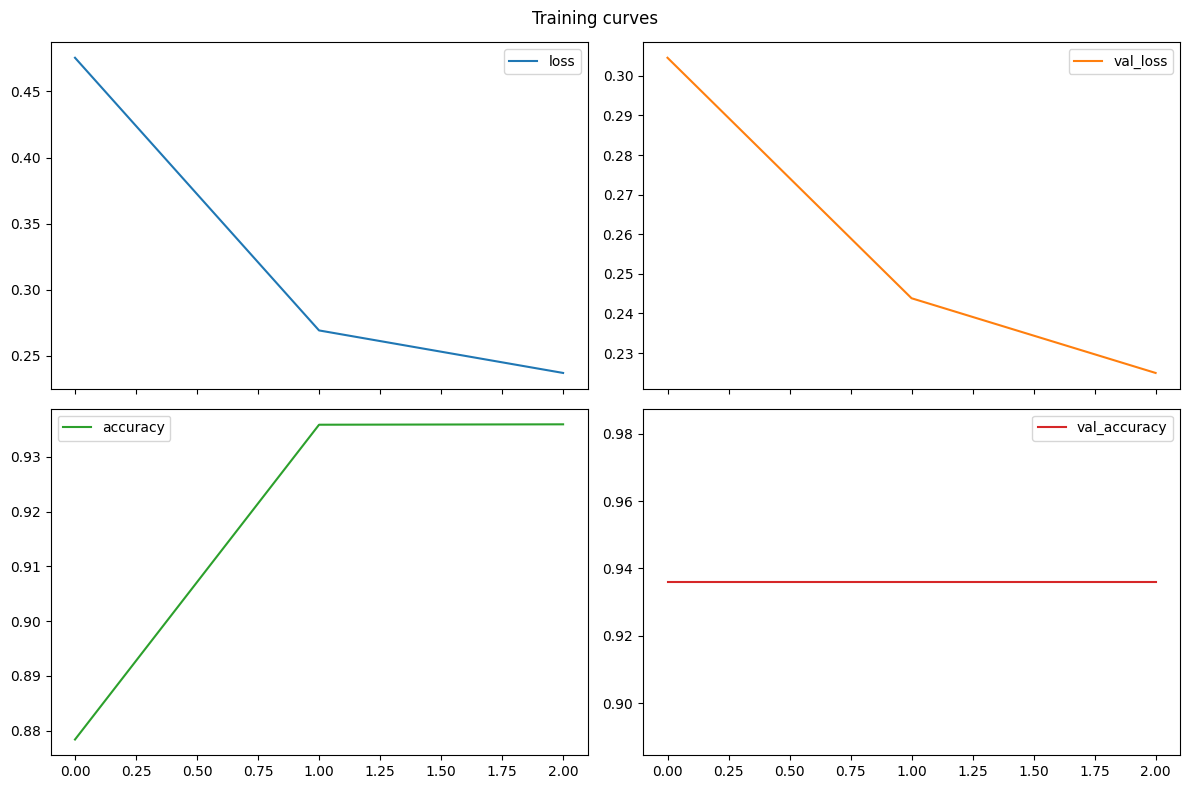

In [17]:
pd.DataFrame(history.history)[['loss', 'val_loss', 'accuracy', 'val_accuracy']].plot(
    subplots=True,
    figsize=(12, 8),
    layout=(2, 2),
    title='Training curves',
)
plt.tight_layout()

## NNLM 128D Experiment

Der konfigurierte Runner trainiert das TF-Hub-Modell, schreibt TensorBoard-Logs und speichert die Historie im Dictionary `histories`.

In [18]:
import importlib
import tfhub_lab.experiments as experiments

importlib.reload(experiments)

histories = globals().get("histories", {})

model_128, history_128, evaluation_128 = experiments.train_named_experiment(
    "nnlm-en-dim128/1",
    train_df=train_df,
    valid_df=valid_df,
    histories=histories,
    epochs=10,
    batch_size=32,
    learning_rate=1e-4,
    log_dir=logdir,
    verbose=1,
)

evaluation_128

Model: "nnlm-en-dim128"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (KerasLayer)      (None, 128)               124642688 
                                                                 
 dense_5 (Dense)             (None, 256)               33024     
                                                                 
 dense_6 (Dense)             (None, 64)                16448     
                                                                 
 dense_7 (Dense)             (None, 1)                 65        
                                                                 
Total params: 124692225 (475.66 MB)
Trainable params: 49537 (193.50 KB)
Non-trainable params: 124642688 (475.47 MB)
_________________________________________________________________
Epoch 1/10
409/409 [==============================] - 1s 1ms/step - loss: 0.2951 - accuracy: 0.9363 - val_loss: 0.2021 - val_accuracy:

{'loss': 0.15326714515686035, 'accuracy': 0.9481825232505798}

## GNews Swivel 20D Fine-Tuning

Dieser Lauf nutzt dasselbe TF-Hub-Modul wie `gnews-swivel-20dim/1`, setzt die Embedding-Schicht aber auf `trainable=True`. Wichtig: Das Modul hat eine Ausgabe-Dimension von `20`, daher ist `embed_size=20` im Projekt-Preset hinterlegt.

In [22]:
import importlib
import tfhub_lab.config as config
import tfhub_lab.experiments as experiments

importlib.reload(config)
importlib.reload(experiments)


histories = globals().get("histories", {})

model_swivel_ft, history_swivel_ft, evaluation_swivel_ft = experiments.train_named_experiment(
    "gnews-swivel-20dim/1-finetuned",
    train_df=train_df,
    valid_df=valid_df,
    histories=histories,
    epochs=10,
    batch_size=32,
    learning_rate=1e-4,
    log_dir=logdir,
    verbose=1,
)

evaluation_swivel_ft

Model: "gnews-swivel-20dim-finetuned"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (KerasLayer)      (None, 20)                400020    
                                                                 
 dense_8 (Dense)             (None, 256)               5376      
                                                                 
 dense_9 (Dense)             (None, 64)                16448     
                                                                 
 dense_10 (Dense)            (None, 1)                 65        
                                                                 
Total params: 421909 (1.61 MB)
Trainable params: 421909 (1.61 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
409/409 [==============================] - 1s 1ms/step - loss: 0.2576 - accuracy: 0.9345 - val_loss: 0.1942 - val_accuracy:

{'loss': 0.17435045540332794, 'accuracy': 0.9427687525749207}

## TensorBoard

Diese Zelle startet TensorBoard direkt im Notebook und liest dieselben Logs, die die Trainingslaeufe unter `logdir` schreiben.

In [23]:
from pathlib import Path

PROJECT_ROOT = globals().get(
    "PROJECT_ROOT",
    Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd(),
)
logdir = Path(globals().get("logdir", PROJECT_ROOT / "logs"))
logdir.mkdir(parents=True, exist_ok=True)

%load_ext tensorboard
%tensorboard --logdir "{logdir}/"

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 23617), started 0:03:51 ago. (Use '!kill 23617' to kill it.)

### Modellvergleich
Die folgenden Diagramme vergleichen Accuracy und Loss aller Eintraege in histories, jeweils fuer Training und Validation.

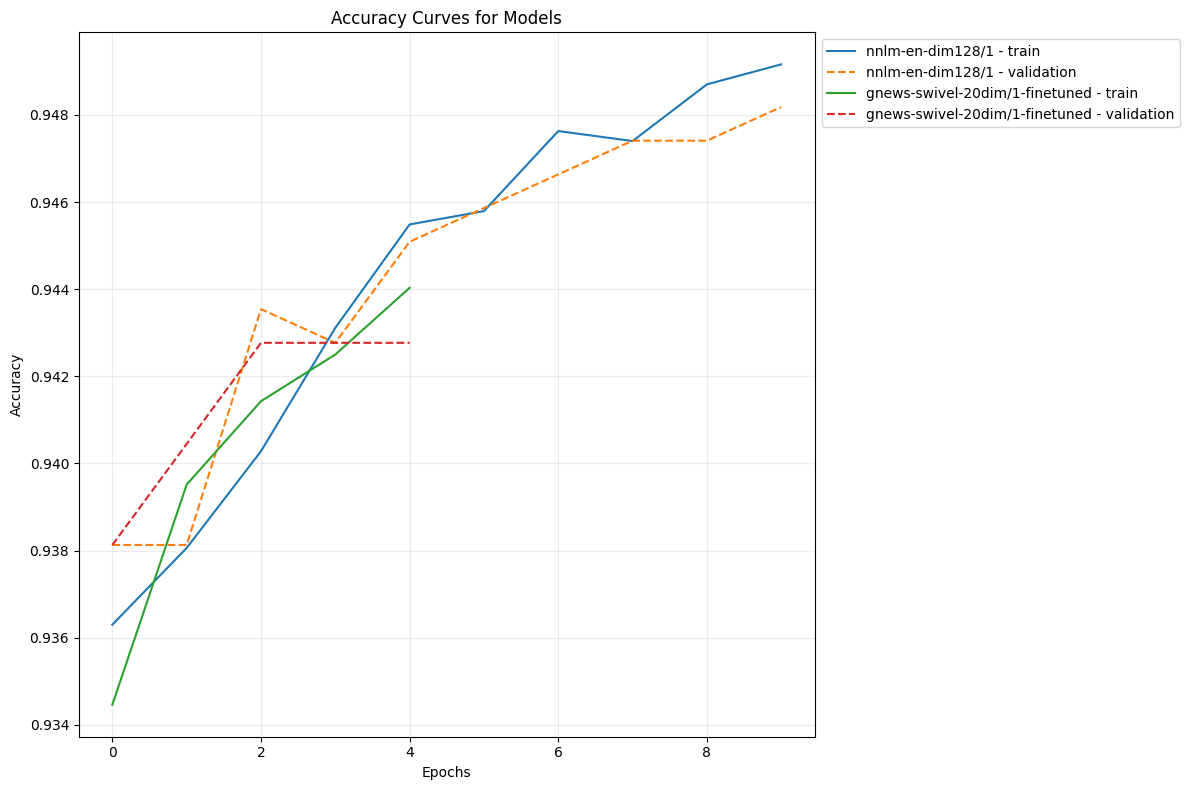

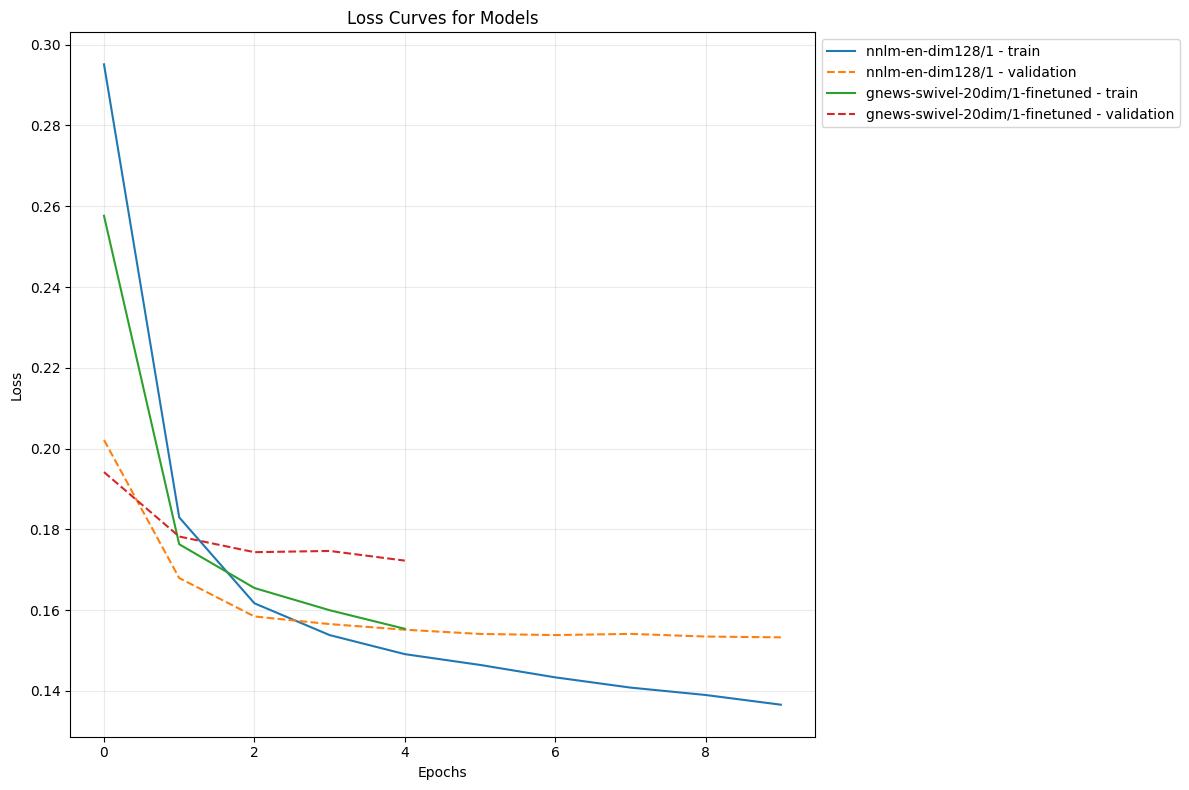

In [24]:
import importlib
import tfhub_lab.experiments as experiments

importlib.reload(experiments)

plt.rcParams["figure.figsize"] = (12, 8)
experiments.plot_accuracy_and_loss(histories)
plt.show()